In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

c:\Users\Admin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Wi

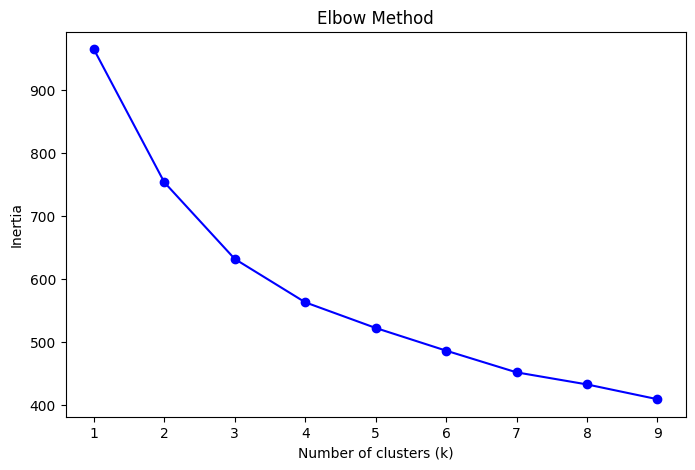

c:\Users\Admin\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster
0    78
2    66
1    49
Name: count, dtype: int64


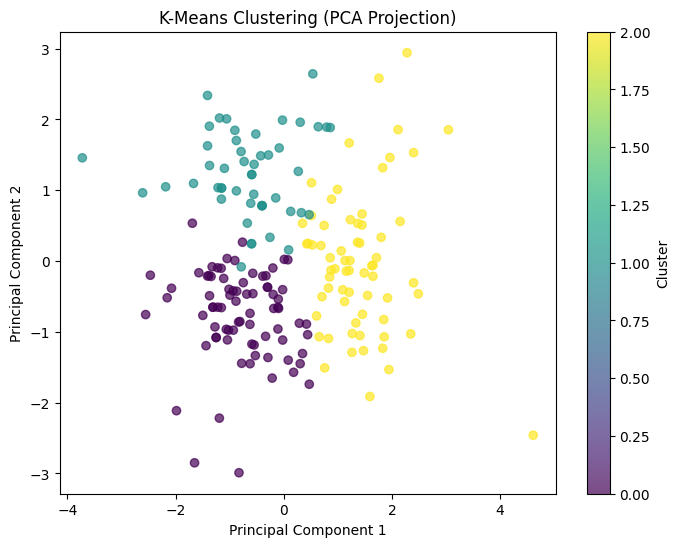

PCA Explained Variance: [0.31242276 0.24587611]


In [ ]:
encoded_df = pd.read_csv("../encoded_dataset.csv")

# features: leisure_hours, self_study_hours, sleep_hours, control_over_habit, focus_frequency
# exclude: delay_until_deadline (binary), timestamp, referrer, data_quality_check


np.random.seed(42)
features = encoded_df[
    [
        "leisure_hours",
        "self_study_hours",
        "sleep_hours",
        "control_over_habit",
        "focus_frequency",
    ]
]

#  Scale
scaler = StandardScaler()
df_scaled = scaler.fit_transform(features) 

#  Elbow graph to find optimal K
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

#test
# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show() 

# Apply K-Means Clustering 
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add the cluster assignments back to the original dataset (FIXED VARIABLE NAME)
encoded_df['Cluster'] = clusters

print(encoded_df['Cluster'].value_counts())

# PCA for 2D Visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (PCA Projection)')
plt.show()

print("PCA Explained Variance:", pca.explained_variance_ratio_)

PCA Loadings
                         PC1       PC2
leisure_hours       0.558522  0.242270
self_study_hours   -0.468023 -0.289303
sleep_hours         0.166622  0.706004
control_over_habit -0.413479  0.467072
focus_frequency    -0.519884  0.375515


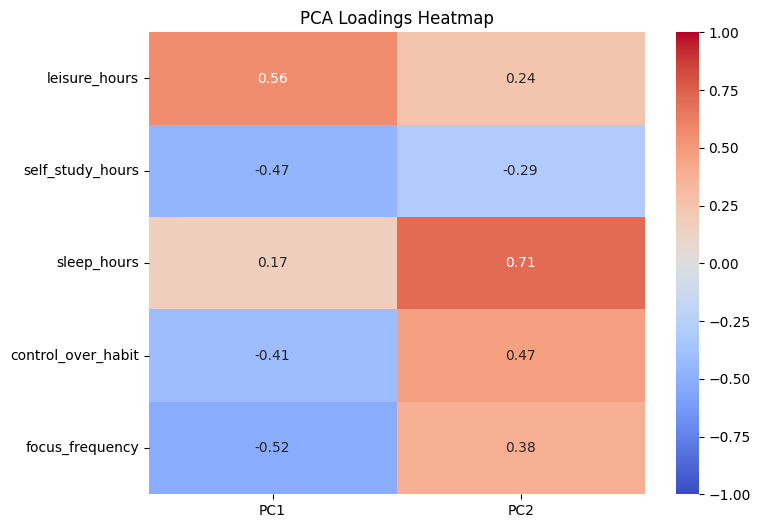

In [5]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=features.columns # Uses the 5 features selected earlier
)

print("PCA Loadings")
print(loadings)

# 2. Plot a Heatmap for easy visual interpretation
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('PCA Loadings Heatmap')
plt.show()